# DQN simulations — **MountainCarContinuous-v0**

Same structure as `dqn_sims.ipynb` (Acrobot). Continuous actions are discretized for DQN.


## Imports


In [29]:
import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F


## Replay Memory for NN training

In [30]:
env = gym.make("MountainCarContinuous-v0")

# Mountain Car Continuous has Box actions in [-1, 1]. DQN needs discrete actions:
# we discretize into evenly spaced throttle values (same training loop as discrete envs).
N_DISCRETE_ACTIONS = 21
DISCRETE_ACTION_VALUES = np.linspace(-1.0, 1.0, N_DISCRETE_ACTIONS, dtype=np.float32)


def discrete_action_to_env(action_index: int) -> np.ndarray:
    """Map discrete DQN action index to the 1D continuous action the env expects."""
    return np.array([float(DISCRETE_ACTION_VALUES[action_index])], dtype=np.float32)

# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print(device)
Transition = namedtuple('Transition',('state', 'action', 'next_state', 'reward'))

mps


In [31]:
class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

## DQN Network ( 3- layerd feefforward Network )

In [32]:
class DQN(nn.Module):

    def __init__(self, n_observations, n_actions):
        super(DQN, self).__init__()
        self.layer1 = nn.Linear(n_observations, 128)
        self.layer2 = nn.Linear(128, 128)
        self.layer3 = nn.Linear(128, n_actions)

    # Called with either one element to determine next action, or a batch
    # during optimization. Returns tensor([[left0exp,right0exp]...]).
    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return self.layer3(x)


## Network Training

In [33]:
# Sparse goal reward + long swing-up: slow ε-decay, larger buffer, moderate LR.
BATCH_SIZE = 256
GAMMA = 0.99
EPS_START = 0.95
EPS_END = 0.05
EPS_DECAY = 40000
TAU = 0.005
LR = 1e-4
MEMORY_CAPACITY = 50_000

# Discrete action count (DQN); env step uses discrete_action_to_env(index)
n_actions = N_DISCRETE_ACTIONS
# Get the number of state observations
state, info = env.reset()
n_observations = len(state)

print(f"Number of actions {n_actions}")
print(f"Number of Observations {n_observations}")

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device) # This is used to compute the Target TD, the weights for this are usually frozen
target_net.load_state_dict(policy_net.state_dict()) # copies all the weights and biases of the police_net to the target_net

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(MEMORY_CAPACITY)

steps_done = 0
episode_durations = []

Number of actions 21
Number of Observations 2


In [34]:
def select_action(state):
    """
    we pick an epislon greedy action
    :param state:
    :return:
    a tensor (1,1) of d_type long, this is needed to ensure torch.gather works later while selecting the Q values from (batch_size, N-actions) from the output of policy_net(states)
    We need thus for the Bellman Loss:
    """
    global steps_done
    sample = random.random()
    # construct the eps decay based on the number of steps done
    eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            # t.max(1) will return the largest column value of each row.
            # second column on max result is index of where max element was
            # found, so we pick action with the larger expected reward.
            return policy_net(state).max(1).indices.view(1, 1) # returns a named tuple with .values and .indices
    else:
        return torch.tensor([[random.randrange(n_actions)]], device=device, dtype=torch.long)

In [35]:
def plot_durations(show_result=False):
    global episode_durations
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Duration')
    plt.plot(durations_t.numpy())
    # Take 20 episode averages and plot them too
    if len(durations_t) >= 20:
        means = durations_t.unfold(0, 20, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(19), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

In [36]:
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    policy_net.train()
    transitions = memory.sample(BATCH_SIZE)
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for
    # detailed explanation). This converts batch-array of Transitions
    # to Transition of batch-arrays.
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    expected_state_action_values = (
        (next_state_values * GAMMA) + reward_batch
    ).unsqueeze(1).detach()

    criterion = nn.SmoothL1Loss()
    with torch.enable_grad():
        state_action_values = policy_net(state_batch).gather(1, action_batch)
        loss = criterion(state_action_values, expected_state_action_values)
        optimizer.zero_grad()
        loss.backward()
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

## Post Training Analysis: Rank-Estimation

In [37]:
from dataclasses import dataclass

MOUNTAIN_CAR_STATE_DIMS = {
    0: "position",
    1: "velocity",
}

@dataclass
class QAnalysis:
    states:   np.ndarray   # (N, 2)  — the sampled states, acts as row index
    q_matrix: np.ndarray   # (N, n_actions)  — Q(s, a) for each discrete action
    v_table:  np.ndarray   # (N,)    — V(s) = max_a Q(s, a)

    def sort_by_dim(self, dim: int) -> "QAnalysis":
        """Return a new QAnalysis sorted by a state dimension."""
        name = MOUNTAIN_CAR_STATE_DIMS.get(dim, f"dim_{dim}")
        print(f"Sorting by state dim {dim} ({name})")
        idx = np.argsort(self.states[:, dim])
        return QAnalysis(
            states   = self.states[idx],
            q_matrix = self.q_matrix[idx],
            v_table  = self.v_table[idx],
        )

    def sort_by_angle(self, dim: int) -> "QAnalysis":
        """
        Mountain Car has no angles; this sorts by state component for API parity
        with the Acrobot notebook. dim 0 = position, dim 1 = velocity.
        """
        if dim not in (0, 1):
            raise ValueError(f"dim must be 0 (position) or 1 (velocity), got {dim}")
        name = MOUNTAIN_CAR_STATE_DIMS[dim]
        print(f"Sorting by {name}")
        idx = np.argsort(self.states[:, dim])
        return QAnalysis(
            states   = self.states[idx],
            q_matrix = self.q_matrix[idx],
            v_table  = self.v_table[idx],
        )

    def sort_by_value(self) -> "QAnalysis":
        """Return a new QAnalysis sorted by V(s) ascending."""
        print("Sorting by V(s)")
        idx = np.argsort(self.v_table)
        return QAnalysis(
            states   = self.states[idx],
            q_matrix = self.q_matrix[idx],
            v_table  = self.v_table[idx],
        )

    def top_k(self, k: int) -> "QAnalysis":
        """Return the k states with highest V(s)."""
        idx = np.argsort(self.v_table)[-k:][::-1]
        return QAnalysis(self.states[idx], self.q_matrix[idx], self.v_table[idx])

    def bottom_k(self, k: int) -> "QAnalysis":
        """Return the k states with lowest V(s)."""
        idx = np.argsort(self.v_table)[:k]
        return QAnalysis(self.states[idx], self.q_matrix[idx], self.v_table[idx])

    def summary(self):
        print(f"States   : {self.states.shape}")
        print(f"Q-matrix : {self.q_matrix.shape}")
        print(f"V-table  : {self.v_table.shape}")
        print(f"V(s) — min: {self.v_table.min():.4f}  max: {self.v_table.max():.4f}  mean: {self.v_table.mean():.4f}")

In [38]:
def estimate_q_analysis(net: DQN, n_samples: int = 512, batch_size: int = 64,) -> QAnalysis:
    states = []

    if len(memory) > 0:
        indices = np.random.choice(
            len(memory),
            size=min(n_samples, len(memory)),
            replace=False,
        )
        for i in indices:
            tr = memory.memory[i]
            if tr.state is not None:
                states.append(tr.state.squeeze(0).cpu().numpy())

    if len(states) < n_samples:
        env_tmp = gym.make("MountainCarContinuous-v0")
        seen = set()
        try:
            while len(states) < n_samples:
                s, _ = env_tmp.reset()
                done = False
                while not done and len(states) < n_samples:
                    key = tuple(np.round(s, 6))
                    if key not in seen:
                        seen.add(key)
                        states.append(np.array(s, copy=True))
                    ai = random.randrange(N_DISCRETE_ACTIONS)
                    a = discrete_action_to_env(ai)
                    s, _, terminated, truncated, _ = env_tmp.step(a)
                    done = terminated or truncated
        finally:
            env_tmp.close()

    states_arr = np.stack(states, axis=0)
    q_chunks   = []

    net.eval()
    with torch.no_grad():
        for start in range(0, len(states_arr), batch_size):
            s_batch = torch.tensor( states_arr[start : start + batch_size], dtype=torch.float32, device=device,)
            q_chunks.append(net(s_batch).cpu().numpy())
    net.train()

    q_matrix = np.concatenate(q_chunks, axis=0)
    v_table  = q_matrix.max(axis=1)                # (N,)

    result = QAnalysis(states=states_arr, q_matrix=q_matrix, v_table=v_table)
    result.summary()
    return result

In [39]:
def build_value_tensor(analysis: QAnalysis, n_bins: int = 100) -> tuple[torch.Tensor, list]:
    """
    Discretise position and velocity into bins and aggregate V(s)
    into a 2D tensor of shape (n_bins, n_bins).

    Returns:
        value_tensor : torch.Tensor  (B, B)
        bin_edges    : list of 2 np.ndarray — bin edges per dim
    """
    states  = analysis.states
    v_table = analysis.v_table

    position = states[:, 0]
    velocity = states[:, 1]

    coords     = [position, velocity]
    dim_names  = ["position", "velocity"]
    bin_edges  = []
    bin_ids    = []

    for coord, name in zip(coords, dim_names):
        edges = np.linspace(coord.min(), coord.max(), n_bins + 1)
        ids   = np.digitize(coord, edges[1:-1])
        bin_edges.append(edges)
        bin_ids.append(ids)
        print(f"{name}: [{coord.min():.3f}, {coord.max():.3f}] → {n_bins} bins")

    value_grid  = np.zeros((n_bins, n_bins))
    count_grid  = np.zeros_like(value_grid)

    for n in range(len(v_table)):
        i, j = bin_ids[0][n], bin_ids[1][n]
        value_grid[i, j] += v_table[n]
        count_grid[i, j] += 1

    empty = count_grid == 0
    value_grid[~empty] /= count_grid[~empty]
    value_grid[empty]   = v_table.mean()

    print(f"\nValue tensor shape : {value_grid.shape}")
    print(f"Empty cells        : {empty.sum()} / {n_bins**2} ({100*empty.mean():.1f}%)")

    return torch.tensor(value_grid, dtype=torch.float32), bin_edges

In [40]:
def plot_tensor_spectrum_tucker(tensor: torch.Tensor, title: str = "Tensor Spectrum (HOSVD)"):
    """
    For 2D tensors : standard SVD spectrum.
    For ND tensors : HOSVD — one singular value spectrum per mode via mode-k unfoldings.

    Args:
        tensor : torch.Tensor of 2 or more dimensions
        title  : plot title string
    """
    import tensorly as tl
    tl.set_backend("pytorch")

    t = tensor.float()

    if t.dim() < 2:
        raise ValueError("Tensor must be at least 2D.")

    mode_spectra = {}
    for k in range(t.dim()):
        unfolded  = tl.unfold(t, mode=k)
        sigmas_k  = torch.linalg.svdvals(unfolded).cpu().numpy()
        stable_rank = float((sigmas_k**2).sum() / sigmas_k[0]**2)
        mode_spectra[f"Mode {k}  (size={t.shape[k]})"] = (sigmas_k, stable_rank)

    print(f"Tensor shape : {tuple(t.shape)}")
    print(f"{'Mode':<30} {'sigma_max':>10} {'sigma_min':>10} {'Effective Rank':>12}")
    print("-" * 65)
    for mode_name, (sigmas, sr) in mode_spectra.items():
        print(f"{mode_name:<30} {sigmas[0]:>10.4f} {sigmas[-1]:>10.6f} {sr:>12.2f}")

    n_modes = len(mode_spectra)
    fig, axes = plt.subplots(1, n_modes, figsize=(5 * n_modes, 4))
    if n_modes == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=13)

    for ax, (mode_name, (sigmas, sr)) in zip(axes, mode_spectra.items()):
        ax.semilogy(sigmas, marker="o", markersize=3, linewidth=1, color="steelblue")
        ax.set_title(f"{mode_name}\nEffective rank: {sr:.2f}")
        ax.set_xlabel("Singular value index")
        ax.set_ylabel("(log scale)")
        ax.grid(True, alpha=0.3, which="both")

    plt.tight_layout()
    plt.savefig("tensor_spectrum_tucker_mountain_car_continuous.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved tensor_spectrum_tucker_mountain_car_continuous.png")

## Simulations of Learnt Policy 

In [41]:
def visualise_policy(net, episodes: int = 3):
    env_vis = gym.make("MountainCarContinuous-v0", render_mode="human")
    try:
        for ep in range(episodes):
            state, _ = env_vis.reset()
            state_t = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            done = False
            steps = 0
            total_reward = 0.0

            while not done:
                with torch.no_grad():
                    q_vals = net(state_t)
                    action_idx = int(q_vals.argmax(dim=1).item())
                obs, reward, terminated, truncated, _ = env_vis.step(discrete_action_to_env(action_idx))
                total_reward += float(reward)
                done = terminated or truncated

                if not done:
                    state_t = torch.tensor(obs, dtype=torch.float32, device=device).unsqueeze(0)

                steps += 1

            print(f"Episode {ep + 1}: {steps} steps, reward {total_reward:.1f}")
    finally:
        env_vis.close()

## Main Code for trainning

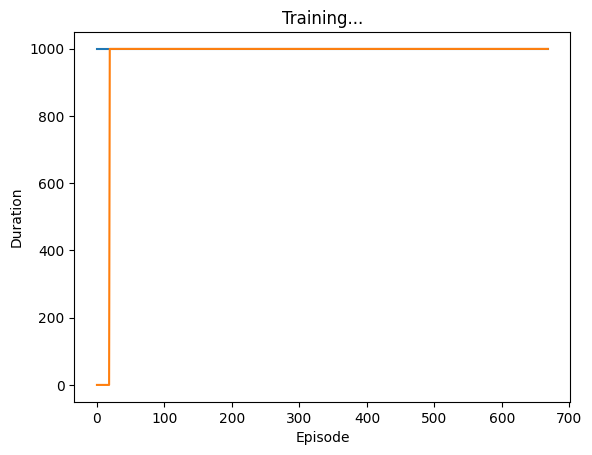

<Figure size 640x480 with 0 Axes>

In [ ]:
if torch.cuda.is_available() or torch.backends.mps.is_available():
    num_episodes = 1000
else:
    num_episodes = 120

for i_episode in range(num_episodes):
    # Initialize the environment and get its state
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    for t in count():
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(discrete_action_to_env(action.item()))
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        # Store the transition in memory
        memory.push(state, action, next_state, reward)

        # Move to the next state
        state = next_state

        # Perform one step of the optimization (on the policy network)
        optimize_model()

        # Soft update of the target network's weights
        # θ′ ← τ θ + (1 −τ )θ′
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key] * TAU + target_net_state_dict[key] * (1 - TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            plot_durations()
            break

print('Complete')
plot_durations(show_result=True)

In [ ]:
print("\nVisualising greedy policy with learned DQN...")
visualise_policy(policy_net, episodes=1)

In [ ]:
analysis    = estimate_q_analysis(policy_net, n_samples=100000, batch_size=256)
by_position = analysis.sort_by_angle(0)

# 2. Convert sorted q_matrix → torch tensor and plot its spectrum
q_tensor = torch.tensor(by_position.q_matrix, dtype=torch.float32)  # (N, n_actions)
plot_tensor_spectrum_tucker(q_tensor, title="Q-matrix Spectrum sorted by position (HOSVD)")

In [ ]:
value_tensor, bin_edges = build_value_tensor(analysis, n_bins=5)
plot_tensor_spectrum_tucker(
    value_tensor,
    title="Value Function Tensor Spectrum (HOSVD)"
)
